# 한국 기업 매출·영업이익 속보 반영 전망 — `korea_rev_op_quick_forecast_v1`

**목적**: 잠정실적(속보)이 발표됐지만 API/DB 에 아직 반영되지 않았을 때, 속보치를 **수동 입력**해서 매출·영업이익 8분기 전망을 **즉시** 업데이트하고 시나리오별로 비교 분석하는 단일 노트북.

| 구분 | 방법 |
|---|---|
| 매출 예측 | `Korea_revenue_forecast_v2` 와 동일한 SARIMA/ETS/Theta + Ensemble |
| 영업이익 예측 | 매출→영업이익 **회귀** (level/diff/log/auto — 적자·흑자 교차 대응) |
| 속보 입력 | `SCENARIOS` 에 분기·매출·영업이익 리스트로 수동 입력 (DB 값 덮어쓰기 가능) |
| 시나리오 | 여러 속보 가정을 동시에 돌려 전망 비교 (DB 기준선 자동 포함) |

> ⚠️ 결과는 **DB(`korea_revenue_forecast_result`)에 저장하지 않습니다** — 정식 예측 파이프라인의 forecast_date 체계 오염 방지. 필요 시 CSV 저장만 지원.

## Cell 1 · 경로 자동 감지 (노트북/데스크탑 공용)

In [1]:
import sys, os, gc, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────
#  프로젝트 루트(= DATA 폴더의 부모)와 DATA 폴더를 sys.path 에 등록.
#  → 노트북/데스크탑 어느 PC 에서 실행해도 동일하게 import 됩니다.
#     from DATA.config import ...            (패키지 import)
#     from universal_ts_forecast_function_v2 import ...  (bare import fallback)
#  ▸ 노트북   : C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast\DATA
#  ▸ 데스크탑 : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA
# ─────────────────────────────────────────────────────────────
_CANDIDATE_ROOTS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast",
    r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy",
]

def _setup_path() -> str:
    try:
        start = Path(__file__).resolve().parent
    except NameError:
        start = Path.cwd()
    for p in [start] + list(start.parents):
        if (p / "DATA").is_dir():
            root = str(p)
            break
    else:
        for cand in _CANDIDATE_ROOTS:
            if os.path.isdir(cand) and os.path.isdir(os.path.join(cand, "DATA")):
                root = cand
                break
        else:
            raise EnvironmentError(
                "DATA 폴더를 찾을 수 없습니다. _CANDIDATE_ROOTS 를 환경에 맞게 수정하세요.")
    data_dir = os.path.join(root, "DATA")
    for p in (root, data_dir):          # 루트 + DATA 폴더 모두 등록
        if p not in sys.path:
            sys.path.insert(0, p)
    print(f"[PATH] root : {root}")
    print(f"[PATH] DATA : {data_dir}")
    return root

_ROOT = _setup_path()


[PATH] root : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[PATH] DATA : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA


## Cell 2 · ★ 입력 변수 (여기만 수정하세요)

- `TICKER` : 분석 종목
- `SCENARIOS` : 속보(잠정실적) 수동 입력 — 시나리오별 리스트
- `ANNOUNCED_UNIT` : 속보 입력값 단위 (기본 억원)
- `REG_METHOD` : 영업이익 회귀 방식 (기본 auto = 백테스트 자동 선택)

In [2]:
# ═══════════════════════════════════════════════════════════════
#  ★★★ 입력 변수 셀 — 이 노트북의 모든 사용자 입력은 여기 한 곳 ★★★
# ═══════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────
#  ① 분석 대상 종목
# ─────────────────────────────────────────────────────────────
TICKER = "A005930"          # 분석 종목 ('005930', 5930, 'A005930' 모두 허용)

# ─────────────────────────────────────────────────────────────
#  ② ★ 속보(잠정실적) 수동 입력 — 시나리오별 리스트
#     · DB 에 아직 반영되지 않은 분기 실적을 여기에 직접 입력합니다.
#     · period  : "YYYYQn" 형식 (예: "2026Q2")
#     · revenue : 발표 매출액   (단위: ANNOUNCED_UNIT)
#     · op      : 발표 영업이익 (단위: ANNOUNCED_UNIT, 적자면 음수,
#                 아직 미발표면 None → 회귀모형으로 자동 추정)
#     · DB 에 이미 있는 분기를 입력하면 → 속보값이 DB 값을 덮어씀
#     · 여러 시나리오를 정의하면 시나리오별 전망을 비교 분석합니다.
# ─────────────────────────────────────────────────────────────
SCENARIOS = {
    "속보반영": [
        {"period": "2026Q2", "revenue": 1762340, "op": 745663},
        # {"period": "2026Q3", "revenue": 780000, "op": None},   # 매출만 발표된 경우
    ],
    # "낙관": [
    #     {"period": "2026Q2", "revenue": 760000, "op": 115000},
    # ],
    # "비관": [
    #     {"period": "2026Q2", "revenue": 700000, "op":  85000},
    # ],
}

ANNOUNCED_UNIT = "억원"     # 속보 입력값의 단위: "원" | "천원" | "백만원" | "억원" | "조원"

INCLUDE_DB_BASELINE = True  # True → 속보 미반영(DB 만) 기준 시나리오를 자동 추가해 비교

# ─────────────────────────────────────────────────────────────
#  ③ 예측 설정
# ─────────────────────────────────────────────────────────────
FORECAST_QUARTERS = 8       # 매출·영업이익 예측 분기 수 (요구사항: 8분기)
MIN_DATA_PERIODS  = 24      # 시계열 예측 최소 관측 분기 수 (24 = 6년)

# ─────────────────────────────────────────────────────────────
#  ④ 영업이익 회귀모형 설정
#     · "level" : OP = α + β·매출 + 분기더미  (적자/흑자 교차 OK, 기본 추천)
#                 → α<0 이면 고정비, β 는 공헌이익률로 해석 가능
#     · "diff"  : ΔOP(YoY) = α + β·Δ매출(YoY)  (전년동기 대비 증감 회귀,
#                 계절성 자동 제거, 적자/흑자 교차 OK)
#     · "log"   : log(OP) = α + β·log(매출)  (전 구간 흑자일 때만,
#                 음수 있으면 자동으로 level 로 폴백)
#     · "auto"  : level 과 diff 를 최근 4분기 홀드아웃 백테스트로 비교해
#                 MAE 가 낮은 쪽 자동 선택 (권장)
# ─────────────────────────────────────────────────────────────
REG_METHOD          = "auto"   # "auto" | "level" | "diff" | "log"
REG_WINDOW_QUARTERS = 24       # 회귀 추정에 사용할 최근 분기 수 (구조변화 반영)
OPM_CLIP            = True     # True → 예측 OPM 을 [과거 최저-10%p, 과거 최고+10%p] 로 제한

# ─────────────────────────────────────────────────────────────
#  ⑤ 시각화 / 출력
# ─────────────────────────────────────────────────────────────
PLOT_TAIL_QUARTERS = 20        # 그래프에 표시할 과거 분기 수
DISPLAY_UNIT       = "억원"    # 표·그래프 표시 단위: "억원" | "조원" | "백만원"

SAVE_CSV = False               # True → 시나리오별 전망 결과를 CSV 저장
CSV_DIR  = (Path(r"C:/reports") if os.name == "nt"
            else Path.home() / "reports")

# ─────────────────────────────────────────────────────────────
#  ⑥ DB / 데이터 (변경 시에만 수정)
# ─────────────────────────────────────────────────────────────
FS_TABLE          = "korea_fs_data_from_DG"   # 재무 원천 테이블 (DataGuide, 값 단위: 천원)
FS_UNIT_MULTIPLIER = 1_000                    # 재무제표 천원 → 원

# 단위 → 원 환산 계수
_UNIT_TO_WON = {"원": 1, "천원": 1_000, "백만원": 1_000_000,
                "억원": 100_000_000, "조원": 1_000_000_000_000}
assert ANNOUNCED_UNIT in _UNIT_TO_WON, f"ANNOUNCED_UNIT 오류: {ANNOUNCED_UNIT}"
assert DISPLAY_UNIT in _UNIT_TO_WON,   f"DISPLAY_UNIT 오류: {DISPLAY_UNIT}"
ANNOUNCED_MULT = _UNIT_TO_WON[ANNOUNCED_UNIT]   # 속보 입력값 → 원
DISPLAY_DIV    = _UNIT_TO_WON[DISPLAY_UNIT]     # 원 → 표시 단위

print("[OK] 입력 변수 설정 완료")
print(f"  종목            : {TICKER}")
print(f"  시나리오        : {list(SCENARIOS.keys())}"
      f"{' + [DB기준]' if INCLUDE_DB_BASELINE else ''}")
print(f"  속보 입력 단위  : {ANNOUNCED_UNIT}   표시 단위: {DISPLAY_UNIT}")
print(f"  예측 분기       : {FORECAST_QUARTERS}Q   OP 회귀: {REG_METHOD}"
      f" (window={REG_WINDOW_QUARTERS}Q)")


[OK] 입력 변수 설정 완료
  종목            : A005930
  시나리오        : ['속보반영'] + [DB기준]
  속보 입력 단위  : 억원   표시 단위: 억원
  예측 분기       : 8Q   OP 회귀: auto (window=24Q)


## Cell 3 · Import & DB 연결

In [3]:
# ═══════════════════════════════════════════════════════════════
#  Import & DB 연결 — 사용자 입력 없음
# ═══════════════════════════════════════════════════════════════
from datetime import datetime
from typing import Union, List, Tuple, Dict, Optional

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

# ── 한글 폰트 자동 설정 (Windows / Mac / Linux) ──────────────────
import matplotlib.font_manager as fm
_installed = {f.name for f in fm.fontManager.ttflist}
for _font in ["Malgun Gothic", "AppleGothic", "NanumGothic"]:
    if _font in _installed:
        plt.rcParams["font.family"] = _font
        break
plt.rcParams["axes.unicode_minus"] = False

# ── 내부 모듈 (경로 자동 감지 덕분에 두 PC 모두 동일하게 import) ──
from DATA.config import get_db_info
from DATA.korea_valuation_helpers import to_dg_ticker, load_korea_financials_wide

# 시계열 예측 모듈: v2 우선, 없으면 v1 폴백
try:
    from DATA.universal_ts_forecast_function_v2 import (
        forecast_sarima, forecast_ets, forecast_theta)
    _TS_MODULE = "universal_ts_forecast_function_v2"
except ImportError:
    from universal_ts_forecast_function import (
        forecast_sarima, forecast_ets, forecast_theta)
    _TS_MODULE = "universal_ts_forecast_function (v1 fallback)"

def log(tag: str, msg: str):
    ts = datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}][{tag}] {msg}", flush=True)

db_info = get_db_info()
TICKER_DG = to_dg_ticker(TICKER)

print(f"[OK] Import 완료  (예측 모듈: {_TS_MODULE})")
print(f"[OK] 분석 종목: {TICKER_DG}")


[OK] Import 완료  (예측 모듈: universal_ts_forecast_function_v2)
[OK] 분석 종목: A005930


## Cell 4 · 데이터 조회 & 속보 병합

- `load_rev_op_history()` : DB에서 매출+영업이익 동시 조회 (`korea_valuation_helpers.load_korea_financials_wide` 재활용 — DG item code 하드코딩 불필요)
- `apply_announcements()` : 속보를 시계열에 병합 (기존 분기 덮어쓰기 / 새 분기 append / 갭 경고)
- 실행 시 DB 원본을 1회 조회하고 최근 8분기를 표시합니다

In [4]:
# ═══════════════════════════════════════════════════════════════
#  1. 데이터 조회 & 속보(잠정실적) 병합 — 사용자 입력 없음
# ═══════════════════════════════════════════════════════════════

def load_rev_op_history(ticker_dg: str) -> pd.DataFrame:
    """
    DB(DataGuide)에서 분기별 매출·영업이익 시계열 조회.

    Returns
    -------
    DataFrame — index: PeriodIndex('Q'), columns: revenue, op (단위: 원)
                revenue 는 필수(결측 분기 제거), op 는 결측 허용(NaN 유지)
    """
    wide = load_korea_financials_wide(
        ticker_dg, db_info, table_name=FS_TABLE,
        item_keys=["revenue", "operating_income"], fillna_zero=False,
    )
    if wide is None or wide.empty or "revenue" not in wide.columns:
        raise ValueError(f"[{ticker_dg}] 매출 데이터 없음 (테이블: {FS_TABLE})")

    df = wide[["revenue", "operating_income"]].copy()
    df.columns = ["revenue", "op"]
    df = df * FS_UNIT_MULTIPLIER                     # 천원 → 원

    # 인덱스 → 분기 PeriodIndex (중복 분기는 마지막 값)
    idx = pd.to_datetime(df.index)
    df.index = pd.PeriodIndex(idx, freq="Q")
    if df.index.duplicated().any():
        df = df.groupby(level=0).last()
    df = df.sort_index()

    df = df[df["revenue"].notna()]                   # 매출 결측 분기 제거
    if df.empty:
        raise ValueError(f"[{ticker_dg}] 유효한 매출 분기 없음")
    return df


def apply_announcements(hist: pd.DataFrame,
                        ann_list: List[dict]) -> Tuple[pd.DataFrame, List[pd.Period]]:
    """
    속보 리스트를 과거 시계열에 병합.
      · DB 에 이미 있는 분기 → 속보값으로 덮어씀 (속보 우선)
      · 새 분기 → append (마지막 분기와 연속인지 검증, 갭 있으면 경고)
      · op=None → 해당 분기 op 는 NaN (이후 회귀모형으로 추정)

    Returns: (병합된 DataFrame, 속보로 입력/수정된 Period 리스트)
    """
    df = hist.copy()
    announced_periods = []

    for item in sorted(ann_list, key=lambda x: pd.Period(x["period"], freq="Q")):
        per = pd.Period(str(item["period"]).strip(), freq="Q")
        rev = item.get("revenue", None)
        op  = item.get("op", None)
        if rev is None:
            raise ValueError(f"속보 {per}: revenue 는 필수입니다.")

        rev_won = float(rev) * ANNOUNCED_MULT
        op_won  = float(op) * ANNOUNCED_MULT if op is not None else np.nan

        if per in df.index:
            old = df.loc[per, "revenue"]
            df.loc[per, "revenue"] = rev_won
            if op is not None:
                df.loc[per, "op"] = op_won
            log("속보", f"{per} DB값 덮어씀: 매출 {old/DISPLAY_DIV:,.0f} → "
                        f"{rev_won/DISPLAY_DIV:,.0f} {DISPLAY_UNIT}")
        else:
            gap = per - df.index[-1]
            if gap.n > 1:
                log("경고", f"{per} 는 마지막 분기({df.index[-1]})와 "
                            f"{gap.n - 1}개 분기 갭 — 중간 분기 미입력 상태로 진행")
            df.loc[per] = {"revenue": rev_won, "op": op_won}
            df = df.sort_index()
        announced_periods.append(per)

    return df, announced_periods


# ── DB 원본 1회 조회 (모든 시나리오가 공유) ─────────────────────
HIST_DB = load_rev_op_history(TICKER_DG)

_n_op = int(HIST_DB["op"].notna().sum())
print(f"[OK] DB 조회 완료: {TICKER_DG}")
print(f"  매출 관측 분기   : {len(HIST_DB)}개 "
      f"({HIST_DB.index[0]} ~ {HIST_DB.index[-1]})")
print(f"  영업이익 관측    : {_n_op}개  "
      f"(적자 분기 {int((HIST_DB['op'] < 0).sum())}개 포함)")
print(f"\n[최근 8개 분기 — 단위: {DISPLAY_UNIT}]")
_tail = (HIST_DB.tail(8) / DISPLAY_DIV).round(0)
_tail["opm(%)"] = (HIST_DB.tail(8)["op"] / HIST_DB.tail(8)["revenue"] * 100).round(1)
_tail.index = _tail.index.astype(str)
display(_tail)

assert len(HIST_DB) >= MIN_DATA_PERIODS, \
    f"매출 관측 {len(HIST_DB)}개 < MIN_DATA_PERIODS({MIN_DATA_PERIODS}) — 시계열 예측 불가"


[OK] DB 조회 완료: A005930
  매출 관측 분기   : 66개 (2009Q4 ~ 2026Q1)
  영업이익 관측    : 66개  (적자 분기 0개 포함)

[최근 8개 분기 — 단위: 억원]


,revenue,op,opm(%)
date,,,
2024Q2,740683.0,104439.0,14.1
2024Q3,790987.0,91834.0,11.6
2024Q4,757883.0,64927.0,8.6
2025Q1,791405.0,66853.0,8.4
2025Q2,745663.0,46761.0,6.3
2025Q3,860617.0,121661.0,14.1
2025Q4,938374.0,200737.0,21.4
2026Q1,1330000.0,572000.0,43.0


## Cell 5 · 매출 시계열 예측 (기존 v2 방식 그대로)

SARIMA / ETS / Theta 3개 모델 + Ensemble(평균), `try_transforms=True`, 계절주기 m=4

In [5]:
# ═══════════════════════════════════════════════════════════════
#  2. 매출 시계열 예측 — Korea_revenue_forecast_v2 와 동일한
#     SARIMA / ETS / Theta + Ensemble 방식 (사용자 입력 없음)
# ═══════════════════════════════════════════════════════════════

def forecast_revenue_ts(series: pd.Series,
                        forecast_quarters: int) -> pd.DataFrame:
    """
    분기 매출 시계열(PeriodIndex, 원) → 향후 forecast_quarters 분기 예측.
    Korea_revenue_forecast_v2 의 _run_models 와 동일 로직.

    Returns
    -------
    DataFrame — index: 예측 PeriodIndex, columns: SARIMA, ETS, Theta, Ensemble (원)
    """
    m = 4  # 분기 계절성

    sarima_result = forecast_sarima(
        y=series, forecast_horizon=forecast_quarters,
        seasonal_period=m, try_transforms=True)
    ets_result = forecast_ets(
        y=series, forecast_horizon=forecast_quarters,
        m=m, try_transforms=True)
    theta_result = forecast_theta(
        y=series, forecast_horizon=forecast_quarters,
        m=m, try_transforms=True)

    fc_index = pd.period_range(start=series.index[-1] + 1,
                               periods=forecast_quarters, freq="Q")
    fc = pd.DataFrame({
        "SARIMA": sarima_result.get("forecast"),
        "ETS":    ets_result.get("forecast"),
        "Theta":  theta_result.get("forecast"),
    }, index=fc_index)
    fc["Ensemble"] = fc[["SARIMA", "ETS", "Theta"]].mean(axis=1)

    # 매출 음수 방어 (변환 실패 등 이례 케이스)
    fc = fc.clip(lower=0)
    return fc

print("[OK] 매출 시계열 예측 함수 정의 완료 (SARIMA/ETS/Theta + Ensemble)")


[OK] 매출 시계열 예측 함수 정의 완료 (SARIMA/ETS/Theta + Ensemble)


## Cell 6 · 영업이익 회귀 예측 모듈

| 방식 | 스펙 | 적자 대응 | 비고 |
|---|---|---|---|
| `level` | OP = α + β·매출 + 분기더미 | ✅ | α<0=고정비, β=공헌이익률 |
| `diff` | ΔOP(YoY) = α + β·Δ매출(YoY) | ✅ | 계절성 자동 제거, 재귀 예측 |
| `log` | log(OP) = α + β·log(매출) | ❌ (자동 level 폴백) | 전 구간 흑자 전용 |
| `auto` | 최근 4분기 홀드아웃 MAE 비교 | ✅ | **기본 권장** |

+ OPM 가드레일: 예측 OPM 을 과거 창의 [최저−10%p, 최고+10%p] 로 제한 (`OPM_CLIP`)

In [6]:
# ═══════════════════════════════════════════════════════════════
#  3. 영업이익 회귀 예측 모듈 — 사용자 입력 없음
#
#  적자/흑자를 오가는 기업까지 다루기 위해 3가지 회귀 스펙 지원:
#   [level] OP = α + β·매출 + 분기더미(Q2,Q3,Q4)
#           · 음수 OP 그대로 사용 가능 (변환 불필요)
#           · α<0 → 고정비, β → 공헌이익률(영업레버리지) 해석
#   [diff]  ΔOP(YoY) = α + β·Δ매출(YoY)
#           · 전년동기 대비 차분 → 계절성 제거 + 음수 OK
#           · 예측은 OP_t = OP_{t-4} + α + β·(매출_t − 매출_{t-4}) 재귀 적용
#   [log]   log(OP) = α + β·log(매출)  — 전 구간 흑자일 때만
#           · 창 내 OP≤0 존재 시 자동으로 level 폴백
#   [auto]  level vs diff(vs log 가능 시)를 최근 4분기 홀드아웃
#           백테스트(MAE)로 비교해 자동 선택
# ═══════════════════════════════════════════════════════════════

def _ols_fit(X: np.ndarray, y: np.ndarray) -> Tuple[np.ndarray, float]:
    """단순 OLS. Returns (beta, R²)."""
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    ss_res = float(np.sum(resid ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 1e-12 else np.nan
    return beta, r2


def _quarter_dummies(periods: pd.PeriodIndex) -> np.ndarray:
    """분기더미 D2, D3, D4 (기준: Q1)."""
    q = np.asarray([p.quarter for p in periods])
    return np.column_stack([(q == 2).astype(float),
                            (q == 3).astype(float),
                            (q == 4).astype(float)])


class OPRegression:
    """
    매출 → 영업이익 회귀모형.
    fit(hist)                        : 과거(매출·OP 동시 관측) 창으로 적합
    predict(fc_rev, hist)            : 예측 매출(Series) → 예측 OP(Series)
    """

    def __init__(self, method: str, window: int, opm_clip: bool):
        self.method_req = method          # 사용자가 요청한 방식
        self.method     = method          # 실제 사용된 방식 (폴백/auto 반영)
        self.window     = window
        self.opm_clip   = opm_clip
        self.coef: Optional[np.ndarray] = None
        self.r2: float = np.nan
        self.n_obs: int = 0
        self.backtest_mae: Dict[str, float] = {}
        self._sample: Optional[pd.DataFrame] = None
        self._opm_lo = -np.inf
        self._opm_hi = np.inf

    # ── 내부: 방식별 적합 ─────────────────────────────────────
    def _fit_level(self, s: pd.DataFrame):
        X = np.column_stack([np.ones(len(s)), s["revenue"].values,
                             _quarter_dummies(s.index)])
        return _ols_fit(X, s["op"].values)

    def _fit_diff(self, s: pd.DataFrame):
        d = pd.DataFrame({
            "d_op":  s["op"]  - s["op"].shift(4),
            "d_rev": s["revenue"] - s["revenue"].shift(4),
        }).dropna()
        if len(d) < 8:
            raise ValueError(f"diff 표본 부족 ({len(d)} < 8)")
        X = np.column_stack([np.ones(len(d)), d["d_rev"].values])
        return _ols_fit(X, d["d_op"].values)

    def _fit_log(self, s: pd.DataFrame):
        if (s["op"] <= 0).any() or (s["revenue"] <= 0).any():
            raise ValueError("log 불가: 창 내 OP≤0 또는 매출≤0 존재")
        X = np.column_stack([np.ones(len(s)), np.log(s["revenue"].values)])
        return _ols_fit(X, np.log(s["op"].values))

    _FITTERS = {"level": "_fit_level", "diff": "_fit_diff", "log": "_fit_log"}

    # ── 내부: 방식별 예측 (단일 분기) ─────────────────────────
    def _pred_one(self, method, coef, per: pd.Period, rev: float,
                  op_lookup, rev_lookup) -> float:
        if method == "level":
            q = per.quarter
            x = np.array([1.0, rev,
                          1.0 if q == 2 else 0.0,
                          1.0 if q == 3 else 0.0,
                          1.0 if q == 4 else 0.0])
            return float(x @ coef)
        if method == "diff":
            base_op  = op_lookup(per - 4)
            base_rev = rev_lookup(per - 4)
            if base_op is None or base_rev is None:
                raise ValueError(f"diff 예측 불가: {per - 4} 기준값 없음")
            return float(base_op + coef[0] + coef[1] * (rev - base_rev))
        if method == "log":
            return float(np.exp(coef[0] + coef[1] * np.log(max(rev, 1.0))))
        raise ValueError(method)

    def _pred_series(self, method, coef, fc_rev: pd.Series,
                     hist: pd.DataFrame) -> pd.Series:
        """예측 매출 시계열 전체에 대해 OP 예측 (diff 는 재귀)."""
        op_hat: Dict[pd.Period, float] = {}

        def op_lookup(p):
            if p in op_hat:
                return op_hat[p]
            if p in hist.index and pd.notna(hist.loc[p, "op"]):
                return float(hist.loc[p, "op"])
            return None

        def rev_lookup(p):
            if p in fc_rev.index:
                return float(fc_rev.loc[p])
            if p in hist.index and pd.notna(hist.loc[p, "revenue"]):
                return float(hist.loc[p, "revenue"])
            return None

        for per in fc_rev.index:
            op_hat[per] = self._pred_one(method, coef, per,
                                         float(fc_rev.loc[per]),
                                         op_lookup, rev_lookup)
        out = pd.Series(op_hat, name="op").sort_index()

        # ── OPM 가드레일: 과거 창의 [최저-10%p, 최고+10%p] 로 제한 ──
        if self.opm_clip:
            opm = (out / fc_rev).clip(self._opm_lo, self._opm_hi)
            out = opm * fc_rev
        return out

    # ── 공개: 적합 ────────────────────────────────────────────
    def fit(self, hist: pd.DataFrame) -> "OPRegression":
        s = hist[["revenue", "op"]].dropna().tail(self.window)
        if len(s) < 12:
            raise ValueError(f"영업이익 회귀 표본 부족 ({len(s)} < 12)")
        self._sample = s
        self.n_obs = len(s)

        hist_opm = s["op"] / s["revenue"]
        self._opm_lo = float(hist_opm.min()) - 0.10
        self._opm_hi = float(hist_opm.max()) + 0.10

        method = self.method_req

        # log 요청인데 음수 존재 → level 폴백
        if method == "log" and (s["op"] <= 0).any():
            log("OP회귀", "창 내 적자 분기 존재 → log 불가, level 로 폴백")
            method = "level"

        # auto → 홀드아웃 백테스트로 선택
        if method == "auto":
            method = self._auto_select(s)

        self.coef, self.r2 = getattr(self, self._FITTERS[method])(s)
        self.method = method
        return self

    def _auto_select(self, s: pd.DataFrame) -> str:
        """최근 4분기 홀드아웃 백테스트 → MAE 최소 방식 선택."""
        H_BT = 4
        if len(s) < 16:                       # 백테스트 여유 없으면 level
            log("OP회귀", f"표본 {len(s)}개 < 16 → 백테스트 생략, level 채택")
            return "level"
        train, test = s.iloc[:-H_BT], s.iloc[-H_BT:]

        candidates = ["level", "diff"]
        if (s["op"] > 0).all() and (s["revenue"] > 0).all():
            candidates.append("log")

        for m in candidates:
            try:
                coef, _ = getattr(self, self._FITTERS[m])(train)
                pred = self._pred_series(
                    m, coef,
                    fc_rev=test["revenue"],
                    hist=train)               # diff 는 train 의 실제 OP 를 기준값으로 사용
                self.backtest_mae[m] = float((pred - test["op"]).abs().mean())
            except Exception as e:
                self.backtest_mae[m] = np.inf
                log("OP회귀", f"백테스트 {m} 실패: {e}")

        best = min(self.backtest_mae, key=self.backtest_mae.get)
        mae_str = "  ".join(f"{k}={v/DISPLAY_DIV:,.0f}"
                            for k, v in self.backtest_mae.items() if np.isfinite(v))
        log("OP회귀", f"[auto] 백테스트 MAE({DISPLAY_UNIT}): {mae_str} → '{best}' 선택")
        return best

    # ── 공개: 예측 ────────────────────────────────────────────
    def predict(self, fc_rev: pd.Series, hist: pd.DataFrame) -> pd.Series:
        assert self.coef is not None, "fit() 을 먼저 호출하세요"
        return self._pred_series(self.method, self.coef, fc_rev, hist)

    # ── 공개: 요약 문자열 ─────────────────────────────────────
    def summary(self) -> str:
        c = self.coef
        if self.method == "level":
            eq = (f"OP = {c[0]/DISPLAY_DIV:+,.0f} + {c[1]:.4f}·매출"
                  f"  (+분기더미 Q2:{c[2]/DISPLAY_DIV:+,.0f}"
                  f" Q3:{c[3]/DISPLAY_DIV:+,.0f} Q4:{c[4]/DISPLAY_DIV:+,.0f})"
                  f"  [단위 {DISPLAY_UNIT}, β=공헌이익률]")
        elif self.method == "diff":
            eq = (f"ΔOP(YoY) = {c[0]/DISPLAY_DIV:+,.0f} + {c[1]:.4f}·Δ매출(YoY)"
                  f"  [단위 {DISPLAY_UNIT}]")
        else:
            eq = f"log(OP) = {c[0]:+.3f} + {c[1]:.3f}·log(매출)"
        return (f"method={self.method} (요청={self.method_req})  "
                f"n={self.n_obs}  R²={self.r2:.3f}\n  {eq}")

print("[OK] 영업이익 회귀 모듈 정의 완료 (level / diff / log / auto)")


[OK] 영업이익 회귀 모듈 정의 완료 (level / diff / log / auto)


## Cell 7 · 시나리오 실행

시나리오마다: 속보 병합 → 매출 8분기 앙상블 예측 → OP 회귀 적합(속보 표본 포함) → OP 8분기 예측. 속보에서 op 미입력 분기는 회귀로 자동 추정.

In [7]:
# ═══════════════════════════════════════════════════════════════
#  4. 시나리오 실행 — 속보 병합 → 매출 TS 예측 → OP 회귀 예측
#     (사용자 입력 없음 — 시나리오는 Cell 2 의 SCENARIOS 에서 정의)
# ═══════════════════════════════════════════════════════════════

def run_scenario(name: str, ann_list: List[dict]) -> Dict:
    """
    단일 시나리오 실행.
      1) DB 시계열에 속보 병합 (덮어쓰기/append)
      2) 병합된 매출 시계열 → SARIMA/ETS/Theta 앙상블 8분기 예측
      3) 매출-영업이익 회귀 적합 (속보로 늘어난 표본 포함)
      4) 속보 분기 중 op 미입력분 + 예측 8분기의 OP 추정
    """
    print(f"\n{'─'*66}\n[시나리오: {name}]  속보 {len(ann_list)}건")
    hist, ann_periods = apply_announcements(HIST_DB, ann_list)

    # ① 매출 시계열 예측 (속보 반영된 마지막 분기 다음부터 8분기)
    fc_rev = forecast_revenue_ts(hist["revenue"], FORECAST_QUARTERS)

    # ② OP 회귀 적합 — 속보 분기 중 매출·OP 모두 있는 것은 표본에 포함
    reg = OPRegression(REG_METHOD, REG_WINDOW_QUARTERS, OPM_CLIP).fit(hist)
    print(f"  OP 회귀: {reg.summary()}")

    # ③ 속보 분기 중 op 미입력분 → 회귀로 추정해 hist 채움 (표시용)
    est_periods = [p for p in ann_periods if pd.isna(hist.loc[p, "op"])]
    if est_periods:
        est = reg.predict(hist.loc[est_periods, "revenue"], hist)
        for p in est_periods:
            hist.loc[p, "op"] = est.loc[p]
        log("속보", f"op 미입력 분기 {[str(p) for p in est_periods]} → 회귀로 추정")

    # ④ 예측 8분기 OP (Ensemble 매출 기준)
    fc_op = reg.predict(fc_rev["Ensemble"], hist)

    fc = pd.DataFrame({
        "revenue": fc_rev["Ensemble"],
        "rev_SARIMA": fc_rev["SARIMA"], "rev_ETS": fc_rev["ETS"],
        "rev_Theta": fc_rev["Theta"],
        "op": fc_op,
    })
    fc["opm"] = fc["op"] / fc["revenue"]

    return {"name": name, "hist": hist, "announced": ann_periods,
            "op_estimated": est_periods, "fc": fc, "reg": reg}


# ── 전체 시나리오 실행 ──────────────────────────────────────────
ALL_SCENARIOS = dict(SCENARIOS)
if INCLUDE_DB_BASELINE:
    ALL_SCENARIOS = {"DB기준(속보 미반영)": [], **ALL_SCENARIOS}

RESULTS: Dict[str, Dict] = {}
for _name, _ann in ALL_SCENARIOS.items():
    try:
        RESULTS[_name] = run_scenario(_name, _ann)
    except Exception as e:
        import traceback
        print(f"  ✗ 시나리오 '{_name}' 실패: {e}")
        traceback.print_exc()

assert RESULTS, "실행에 성공한 시나리오가 없습니다."
print(f"\n[OK] {len(RESULTS)}/{len(ALL_SCENARIOS)} 시나리오 실행 완료")



──────────────────────────────────────────────────────────────────
[시나리오: DB기준(속보 미반영)]  속보 0건
[메모리] forecast_sarima 실행 전: 430.41 MB
[메모리] find_best_sarima_params 실행 전: 430.43 MB
[메모리] find_best_sarima_params 실행 후: 435.55 MB (변화: +5.12 MB)
[메모리] forecast_sarima 실행 후: 435.60 MB (변화: +5.18 MB)
[메모리] forecast_ets 실행 전: 435.60 MB
[메모리] forecast_ets 실행 후: 435.88 MB (변화: +0.29 MB)
[메모리] forecast_theta 실행 전: 435.88 MB
[메모리] forecast_theta 실행 후: 436.05 MB (변화: +0.17 MB)
[21:07:05][OP회귀] [auto] 백테스트 MAE(억원): level=142,759  diff=66,742  log=35,173 → 'log' 선택
  OP 회귀: method=log (요청=auto)  n=24  R²=0.375
  log(OP) = -80.285 + 3.443·log(매출)

──────────────────────────────────────────────────────────────────
[시나리오: 속보반영]  속보 1건
[메모리] forecast_sarima 실행 전: 436.20 MB
[메모리] find_best_sarima_params 실행 전: 436.20 MB
[메모리] find_best_sarima_params 실행 후: 436.84 MB (변화: +0.64 MB)
[메모리] forecast_sarima 실행 후: 436.84 MB (변화: +0.64 MB)
[메모리] forecast_ets 실행 전: 436.84 MB
[메모리] forecast_ets 실행 후: 436.84 MB (변화: +

## Cell 8 · 결과 요약 테이블

① 시나리오별 8분기 상세 (모델별 매출 + 영업이익 + OPM) → ② 시나리오 비교표 → ③ 향후 4Q/8Q 합계 요약

In [8]:
# ═══════════════════════════════════════════════════════════════
#  5. 결과 요약 — 시나리오별 8분기 전망 테이블 & 비교표
# ═══════════════════════════════════════════════════════════════

def _fmt(df: pd.DataFrame) -> pd.DataFrame:
    """원 단위 → DISPLAY_UNIT 반올림 표시용 변환."""
    out = df.copy()
    for c in out.columns:
        if c != "opm(%)":
            out[c] = (out[c] / DISPLAY_DIV).round(0)
    return out

# ── ① 시나리오별 상세 8분기 전망 ────────────────────────────────
for name, r in RESULTS.items():
    fc = r["fc"]
    tbl = pd.DataFrame({
        "매출(Ensemble)": fc["revenue"],
        "매출(SARIMA)":   fc["rev_SARIMA"],
        "매출(ETS)":      fc["rev_ETS"],
        "매출(Theta)":    fc["rev_Theta"],
        "영업이익":        fc["op"],
    })
    tbl["opm(%)"] = (fc["opm"] * 100).round(1)
    tbl = _fmt(tbl)
    tbl.index = tbl.index.astype(str)

    print(f"\n{'='*70}")
    print(f"[{name}]  향후 {FORECAST_QUARTERS}분기 전망  (단위: {DISPLAY_UNIT})")
    if r["announced"]:
        est_note = (f" (op 회귀추정: {[str(p) for p in r['op_estimated']]})"
                    if r["op_estimated"] else "")
        print(f"  반영 속보 분기: {[str(p) for p in r['announced']]}{est_note}")
    print(f"{'='*70}")
    display(tbl)

# ── ② 시나리오 비교표 (매출 / 영업이익 / OPM) ───────────────────
if len(RESULTS) > 1:
    cmp_rev = pd.DataFrame({n: r["fc"]["revenue"] for n, r in RESULTS.items()})
    cmp_op  = pd.DataFrame({n: r["fc"]["op"]      for n, r in RESULTS.items()})
    cmp_opm = pd.DataFrame({n: r["fc"]["opm"]*100 for n, r in RESULTS.items()})
    for label, cmp_df, is_pct in [("매출", cmp_rev, False),
                                  ("영업이익", cmp_op, False),
                                  ("OPM(%)", cmp_opm, True)]:
        show = cmp_df.round(1) if is_pct else (cmp_df / DISPLAY_DIV).round(0)
        show.index = show.index.astype(str)
        print(f"\n[시나리오 비교 — {label}"
              f"{'' if is_pct else f' (단위: {DISPLAY_UNIT})'}]")
        display(show)

# ── ③ 연환산 요약: 향후 4Q / 8Q 합계 ────────────────────────────
_rows = []
for name, r in RESULTS.items():
    fc = r["fc"]
    _rows.append({
        "시나리오": name,
        f"매출 4Q합({DISPLAY_UNIT})":     fc["revenue"].iloc[:4].sum() / DISPLAY_DIV,
        f"영업이익 4Q합({DISPLAY_UNIT})": fc["op"].iloc[:4].sum() / DISPLAY_DIV,
        "OPM 4Q(%)": fc["op"].iloc[:4].sum() / fc["revenue"].iloc[:4].sum() * 100,
        f"매출 8Q합({DISPLAY_UNIT})":     fc["revenue"].sum() / DISPLAY_DIV,
        f"영업이익 8Q합({DISPLAY_UNIT})": fc["op"].sum() / DISPLAY_DIV,
        "OPM 8Q(%)": fc["op"].sum() / fc["revenue"].sum() * 100,
    })
summary_annual = pd.DataFrame(_rows).set_index("시나리오").round(1)
print(f"\n[연환산 요약 — 향후 4분기 / 8분기 합계]")
display(summary_annual)



[DB기준(속보 미반영)]  향후 8분기 전망  (단위: 억원)


,매출(Ensemble),매출(SARIMA),매출(ETS),매출(Theta),영업이익,opm(%)
2026Q2,1345446.0,1334452.0,1361070.0,1340816.0,608877.0,45.3
2026Q3,1443106.0,1461973.0,1454321.0,1413023.0,764955.0,53.0
2026Q4,1438648.0,1397503.0,1485431.0,1433010.0,762592.0,53.0
2027Q1,1449204.0,1521288.0,1476032.0,1350291.0,768187.0,53.0
2027Q2,1448790.0,1463172.0,1510514.0,1372684.0,767968.0,53.0
2027Q3,1548072.0,1583554.0,1614003.0,1446657.0,820594.0,53.0
2027Q4,1549084.0,1531593.0,1648529.0,1467129.0,821131.0,53.0
2028Q1,1556456.0,1648895.0,1638098.0,1382375.0,825039.0,53.0



[속보반영]  향후 8분기 전망  (단위: 억원)
  반영 속보 분기: ['2026Q2']


,매출(Ensemble),매출(SARIMA),매출(ETS),매출(Theta),영업이익,opm(%)
2026Q3,2012679.0,2296200.0,1883035.0,1858801.0,974840.0,48.4
2026Q4,2130992.0,2601173.0,1923223.0,1868579.0,1084945.0,50.9
2027Q1,2250818.0,3064281.0,1911019.0,1777154.0,1193103.0,53.0
2027Q2,2415182.0,3452328.0,1985550.0,1807668.0,1216894.0,50.4
2027Q3,2694471.0,4055118.0,2121531.0,1906763.0,1428272.0,53.0
2027Q4,2827542.0,4399025.0,2166810.0,1916791.0,1498810.0,53.0
2028Q1,3030924.0,5116783.0,2153060.0,1822928.0,1606617.0,53.0
2028Q2,3274536.0,5732334.0,2237031.0,1854243.0,1735750.0,53.0



[시나리오 비교 — 매출 (단위: 억원)]


...

,DB기준(속보 미반영),속보반영
2026Q2,608877.0,NaN
2026Q3,764955.0,974840.0
2026Q4,762592.0,1084945.0
2027Q1,768187.0,1193103.0
2027Q2,767968.0,1216894.0
2027Q3,820594.0,1428272.0
2027Q4,821131.0,1498810.0
2028Q1,825039.0,1606617.0
2028Q2,NaN,1735750.0



[시나리오 비교 — OPM(%)]


,DB기준(속보 미반영),속보반영
2026Q2,45.3,NaN
2026Q3,53.0,48.4
2026Q4,53.0,50.9
2027Q1,53.0,53.0
2027Q2,53.0,50.4
2027Q3,53.0,53.0
2027Q4,53.0,53.0
2028Q1,53.0,53.0
2028Q2,NaN,53.0



[연환산 요약 — 향후 4분기 / 8분기 합계]


,매출 4Q합(억원),영업이익 4Q합(억원),OPM 4Q(%),매출 8Q합(억원),영업이익 8Q합(억원),OPM 8Q(%)
시나리오,,,,,,
DB기준(속보 미반영),5676403.5,2904610.0,51.2,11778804.7,6139341.5,52.1
속보반영,8809670.6,4469782.0,50.7,20637142.8,10739231.5,52.0


## Cell 9 · 시각화 — 매출 / 영업이익 / OPM

회색 실선 = DB 실적, ★ = 속보 입력 분기, 컬러 점선 = 시나리오별 전망, 음영 = 매출 모델(SARIMA~Theta) 범위

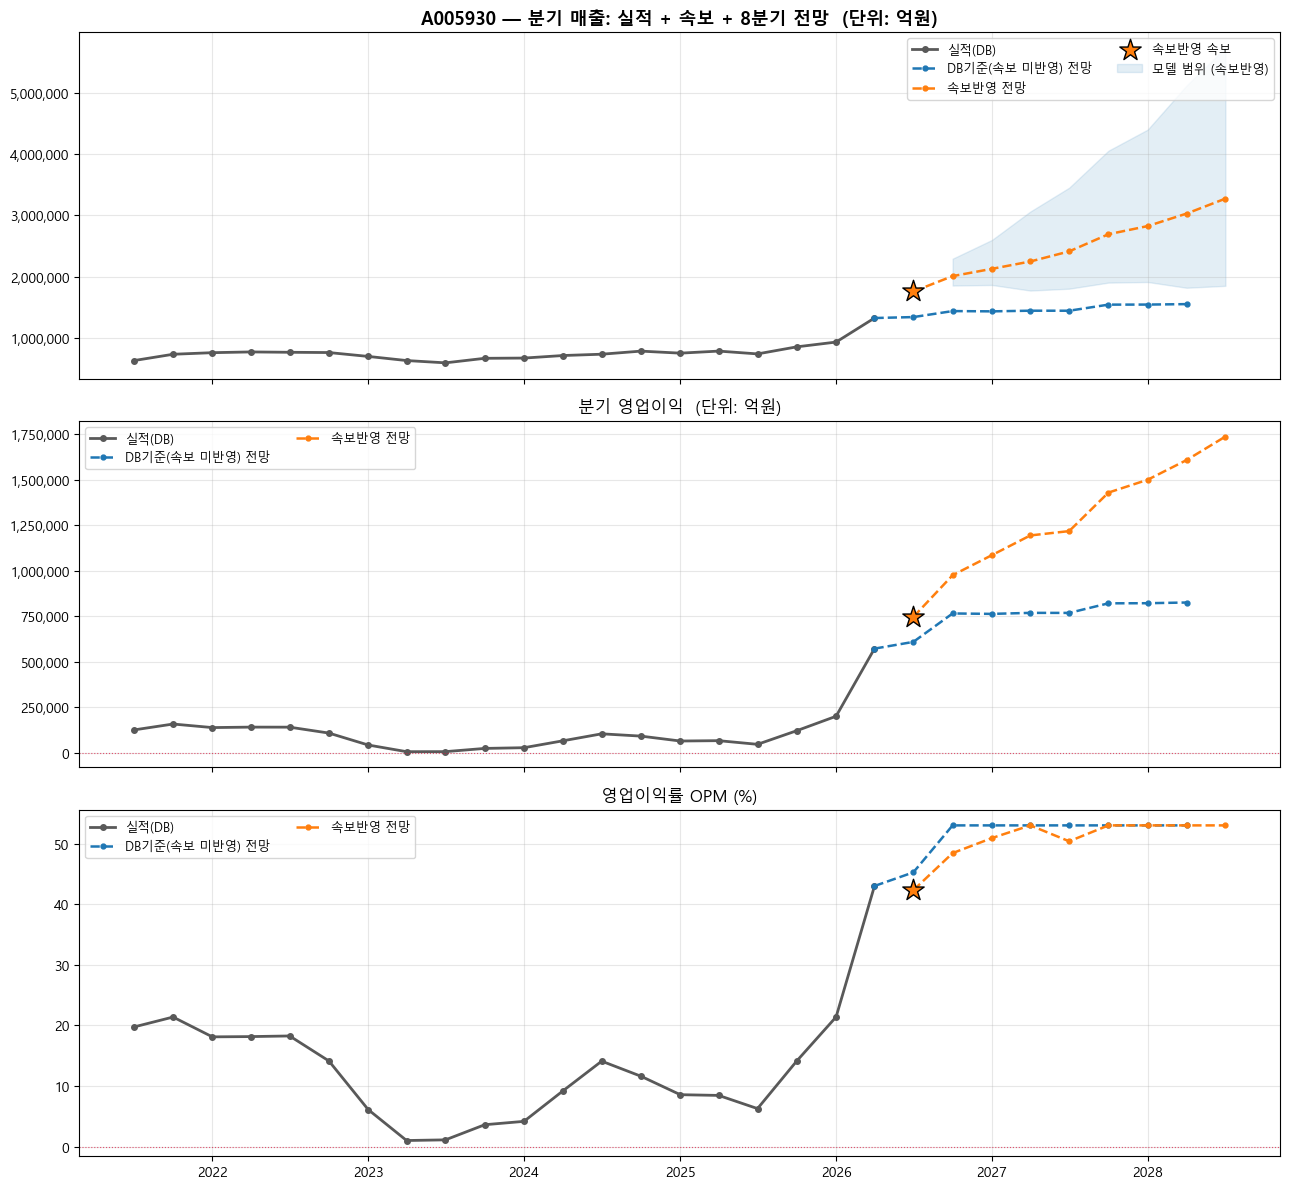

In [9]:
# ═══════════════════════════════════════════════════════════════
#  6. 시각화 — 매출 / 영업이익 / OPM 3단 차트
#     · 실선(회색): 과거 실적 (DB)
#     · ★ 마커: 속보(잠정실적) 입력 분기
#     · 점선(컬러): 시나리오별 향후 8분기 전망
# ═══════════════════════════════════════════════════════════════

def _ts(idx: pd.PeriodIndex):
    return idx.to_timestamp(how="end")

_COLORS = plt.cm.tab10.colors
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)
ax_rev, ax_op, ax_opm = axes

hist_tail = HIST_DB.tail(PLOT_TAIL_QUARTERS)

# ── 과거 실적 (DB, 모든 시나리오 공통) ──────────────────────────
ax_rev.plot(_ts(hist_tail.index), hist_tail["revenue"] / DISPLAY_DIV,
            color="0.35", lw=2, marker="o", ms=4, label="실적(DB)")
ax_op.plot(_ts(hist_tail.index), hist_tail["op"] / DISPLAY_DIV,
           color="0.35", lw=2, marker="o", ms=4, label="실적(DB)")
ax_opm.plot(_ts(hist_tail.index),
            hist_tail["op"] / hist_tail["revenue"] * 100,
            color="0.35", lw=2, marker="o", ms=4, label="실적(DB)")

# ── 시나리오별: 속보 마커 + 전망선 ──────────────────────────────
for k, (name, r) in enumerate(RESULTS.items()):
    color = _COLORS[k % len(_COLORS)]
    hist, fc, ann = r["hist"], r["fc"], r["announced"]

    # 전망선 연결감을 위해 마지막 실적 분기를 전망선 앞에 붙임
    last_p = hist.index[-1]
    rev_line = pd.concat([hist["revenue"].loc[[last_p]], fc["revenue"]])
    op_line  = pd.concat([hist["op"].loc[[last_p]],      fc["op"]])
    opm_line = op_line / rev_line * 100

    ax_rev.plot(_ts(rev_line.index), rev_line / DISPLAY_DIV,
                color=color, lw=1.8, ls="--", marker="o", ms=3.5,
                label=f"{name} 전망")
    ax_op.plot(_ts(op_line.index), op_line / DISPLAY_DIV,
               color=color, lw=1.8, ls="--", marker="o", ms=3.5,
               label=f"{name} 전망")
    ax_opm.plot(_ts(opm_line.index), opm_line,
                color=color, lw=1.8, ls="--", marker="o", ms=3.5,
                label=f"{name} 전망")

    # 속보 분기 ★ 마커 (속보 반영값)
    if ann:
        ann_idx = pd.PeriodIndex(ann, freq="Q")
        ax_rev.scatter(_ts(ann_idx), hist.loc[ann_idx, "revenue"] / DISPLAY_DIV,
                       marker="*", s=260, color=color, edgecolor="k",
                       zorder=5, label=f"{name} 속보")
        ax_op.scatter(_ts(ann_idx), hist.loc[ann_idx, "op"] / DISPLAY_DIV,
                      marker="*", s=260, color=color, edgecolor="k", zorder=5)
        ax_opm.scatter(_ts(ann_idx),
                       hist.loc[ann_idx, "op"] / hist.loc[ann_idx, "revenue"] * 100,
                       marker="*", s=260, color=color, edgecolor="k", zorder=5)

# ── 매출 예측 모델 밴드 (첫 번째 속보 시나리오 기준 SARIMA~Theta 범위) ──
_band_src = next((r for n, r in RESULTS.items() if r["announced"]),
                 next(iter(RESULTS.values())))
_models = _band_src["fc"][["rev_SARIMA", "rev_ETS", "rev_Theta"]]
ax_rev.fill_between(_ts(_models.index),
                    _models.min(axis=1) / DISPLAY_DIV,
                    _models.max(axis=1) / DISPLAY_DIV,
                    alpha=0.12, color="tab:blue",
                    label=f"모델 범위 ({_band_src['name']})")

# ── 꾸미기 ──────────────────────────────────────────────────────
ax_op.axhline(0, color="crimson", lw=0.8, ls=":", alpha=0.7)
ax_opm.axhline(0, color="crimson", lw=0.8, ls=":", alpha=0.7)
ax_rev.set_title(f"{TICKER_DG} — 분기 매출: 실적 + 속보 + {FORECAST_QUARTERS}분기 전망"
                 f"  (단위: {DISPLAY_UNIT})", fontsize=13, fontweight="bold")
ax_op.set_title(f"분기 영업이익  (단위: {DISPLAY_UNIT})", fontsize=12)
ax_opm.set_title("영업이익률 OPM (%)", fontsize=12)
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(loc="best", fontsize=9, ncol=2)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()


## Cell 10 · (선택) CSV 저장 — `SAVE_CSV=True` 일 때만

In [ ]:
# ═══════════════════════════════════════════════════════════════
#  7. (선택) CSV 저장 — SAVE_CSV=True 일 때만
#
#  ※ 주의: 이 노트북의 결과는 korea_revenue_forecast_result 테이블에
#     저장하지 않습니다. 속보 기반 시나리오 값이 정식 예측 파이프라인
#     (Korea_revenue_forecast_v2 → FCFF/RIM)의 forecast_date 체계와
#     섞이면 부분실행 오염과 같은 문제가 생길 수 있기 때문입니다.
#     정식 반영은 DB 업데이트 후 Korea_revenue_forecast_v2 재실행으로.
# ═══════════════════════════════════════════════════════════════

if SAVE_CSV:
    CSV_DIR.mkdir(parents=True, exist_ok=True)
    stamp = datetime.now().strftime("%Y%m%d")
    rows = []
    for name, r in RESULTS.items():
        fc = r["fc"].copy()
        fc.insert(0, "scenario", name)
        fc.insert(1, "ticker", TICKER_DG)
        fc.index.name = "period"
        rows.append(fc.reset_index())
    out = pd.concat(rows, ignore_index=True)
    out["period"] = out["period"].astype(str)
    path = CSV_DIR / f"{TICKER_DG}_rev_op_scenario_{stamp}.csv"
    out.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"[OK] CSV 저장: {path}  ({len(out)}행, 값 단위: 원)")
else:
    print("[SKIP] SAVE_CSV=False — CSV 저장 생략")
